# **Análisis Exploratorio del dataset** ***'acc_intakes_outcomes.csv'***

## 1. Configuración, lectura del csv e ingeniería de características

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import shap
import json

# =========================================================
# 0. CONFIGURACIÓN DE ESTILOS
# =========================================================
bg_color = '#022135'
text_color = '#ffffff'
accent_color = '#b5b462'
palette_custom = [accent_color, '#5a8b8b', '#e07a5f']

plt.rcParams.update({
    'figure.facecolor': bg_color,
    'axes.facecolor': bg_color,
    'axes.edgecolor': text_color,
    'axes.labelcolor': text_color,
    'text.color': text_color,
    'xtick.color': text_color,
    'ytick.color': text_color,
    'grid.color': '#113a5c', 
    'legend.facecolor': bg_color,
    'legend.edgecolor': text_color,
    'axes.prop_cycle': plt.cycler(color=palette_custom)
})

# =========================================================
# 1. CARGA Y FILTRADO RIGUROSO
# =========================================================
df = pd.read_csv("aac_intakes_outcomes.csv")
df['intake_datetime'] = pd.to_datetime(df['intake_datetime'])
df = df.sort_values('intake_datetime')

valid_intakes = ['Stray', 'Owner Surrender', 'Public Assist']
df_filtered = df[df['intake_type'].isin(valid_intakes)].copy()

# =========================================================
# 2. INGENIERÍA DE CARACTERÍSTICAS
# =========================================================
# 2.1 Edad categórica
df_filtered['age_in_years'] = df_filtered['age_upon_intake_(years)'].fillna(0)
df_filtered['is_puppy_kitten'] = (df_filtered['age_in_years'] < 1.0).astype(int)
df_filtered['is_senior'] = (df_filtered['age_in_years'] >= 8.0).astype(int)

# 2.2 Heurísticas de Razas Específicas
breed_lower = df_filtered['breed'].str.lower()
df_filtered['is_mix'] = breed_lower.str.contains('mix', na=False).astype(int)
df_filtered['is_pitbull'] = breed_lower.str.contains('pit bull|staffordshire', na=False).astype(int)
df_filtered['is_chihuahua'] = breed_lower.str.contains('chihuahua', na=False).astype(int)
df_filtered['is_labrador'] = breed_lower.str.contains('labrador|retriever', na=False).astype(int)
df_filtered['is_shepherd'] = breed_lower.str.contains('shepherd', na=False).astype(int)
df_filtered['is_husky'] = breed_lower.str.contains('husky|malamute', na=False).astype(int)

# 2.3 Tamaño de la Raza (Mapeo por palabras clave)
small_keywords = ['chihuahua', 'dachshund', 'poodle', 'yorkshire', 'rat terrier', 'jack russell', 'schnauzer', 'shih tzu', 'pug', 'pomeranian', 'cairn'] 
medium_keywords = ['pit bull', 'cattle dog', 'border collie', 'boxer', 'australian shepherd', 'beagle', 'staffordshire', 'catahoula', 'pointer', 'bulldog']
large_keywords = ['labrador', 'german shepherd', 'husky', 'pyrenees', 'rottweiler', 'mastiff', 'dane', 'bernard', 'retriever', 'hound']

def assign_size(breed):
    if not isinstance(breed, str): return 'Unknown'
    b = breed.lower()
    if any(k in b for k in large_keywords): return 'Large'
    if any(k in b for k in medium_keywords): return 'Medium'
    if any(k in b for k in small_keywords): return 'Small'
    return 'Medium'

df_filtered['breed_size'] = df_filtered['breed'].apply(assign_size)

# Target logarítmico para normalizar la asimetría
target = 'time_in_shelter_days'
df_filtered['target_log'] = np.log1p(df_filtered[target])

## 2. Arquitectura de modelos para la predicción

Entrenamiento completado exitosamente.


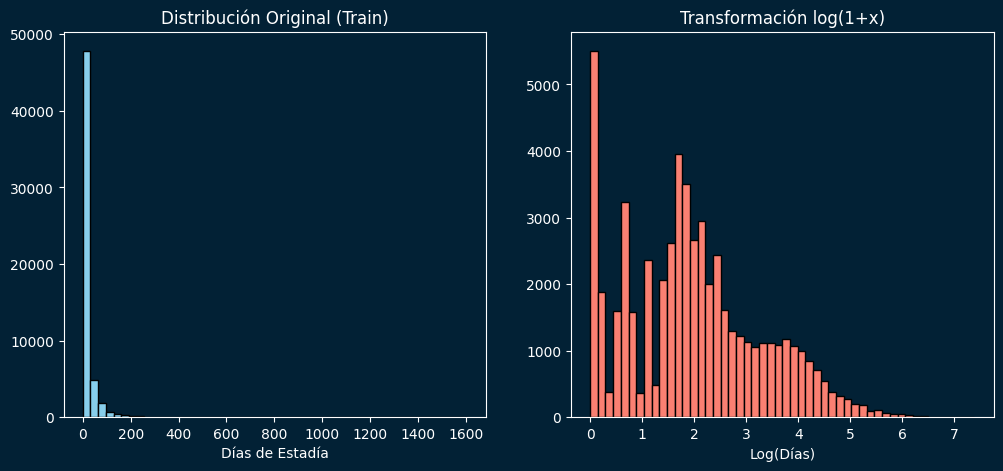

In [32]:
# =========================================================
# 3. PARTICIÓN TEMPORAL Y PREPROCESAMIENTO
# =========================================================
cutoff_date = '2017-01-01'
train = df_filtered[df_filtered['intake_datetime'] < cutoff_date].copy()
test = df_filtered[df_filtered['intake_datetime'] >= cutoff_date].copy()

categorical_features = ['animal_type', 'intake_type', 'intake_condition', 'sex_upon_intake', 'breed_size']
numeric_features = ['age_in_years', 'is_puppy_kitten', 'is_senior', 'is_mix', 'is_pitbull', 'is_chihuahua', 'is_labrador', 'is_shepherd', 'is_husky']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train['time_in_shelter_days'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribución Original (Train)")
plt.xlabel("Días de Estadía")

plt.subplot(1, 2, 2)
plt.hist(train['target_log'], bins=50, color='salmon', edgecolor='black')
plt.title("Transformación log(1+x)")
plt.xlabel("Log(Días)")

X_train = train[categorical_features + numeric_features]
y_train = train['target_log']
X_test = test[categorical_features + numeric_features]
y_test = test['target_log']
y_test_real = test[target]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================================================
# 4. ENTRENAMIENTO MULTI-MODELO
# =========================================================
models = {
    'Regresion Lineal': LinearRegression(),
    'Red Neuronal (MLP)': MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42),
    'Gradient Boosting (XGB)': HistGradientBoostingRegressor(random_state=42, max_iter=200, max_depth=7, learning_rate=0.08)
}

results = []
best_model = None

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    
    y_pred_log = pipe.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    
    r2 = r2_score(y_test, y_pred_log)
    medae = median_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    results.append({
        'Modelo': name,
        'R2': r2,
        'MedAE (Dias)': medae,
        'RMSE (Dias)': rmse
    })
    
    if name == 'Gradient Boosting (XGB)':
        best_model = pipe

results_df = pd.DataFrame(results)
print("Entrenamiento completado exitosamente.")

#### Ejemplo del animal con más tiempo en el refugio

In [33]:
df_filtered[df_filtered['time_in_shelter_days'] == df_filtered['time_in_shelter_days'].max()][['animal_type','breed','age_in_years','time_in_shelter_days']]

,animal_type,breed,age_in_years,time_in_shelter_days
5500,Dog,Chihuahua Shorthair Mix,7.0,1606.194444


#### Promedio de estancia en el refugio por tipo de animal
Se espera que el modelo aprenda que los gatos tienen más tiempo de estancia medio

<Axes: xlabel='animal_type', ylabel='time_in_shelter_days'>

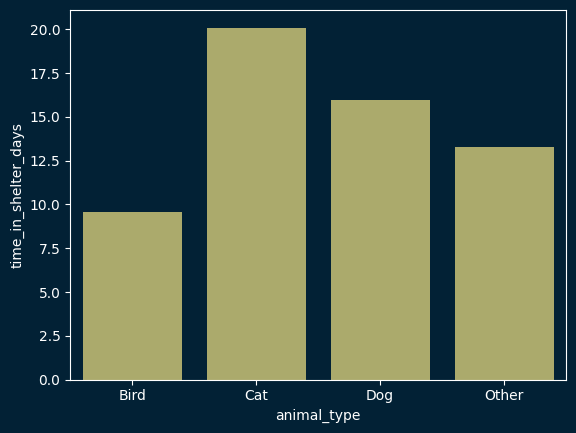

In [34]:
sns.barplot(data=df_filtered.groupby('animal_type')['time_in_shelter_days'].mean().reset_index(),x='animal_type',y='time_in_shelter_days')

#### Comparativa de la edad de los animales y el tiempo se estancia en el refugio

<Axes: xlabel='age_in_years', ylabel='time_in_shelter_days'>

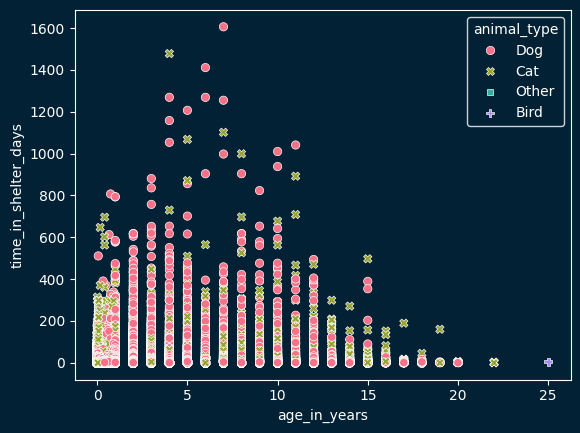

In [40]:
sns.scatterplot(
    data=df_filtered, 
    x='age_in_years', 
    y='time_in_shelter_days', 
    hue='animal_type', 
    style='animal_type'
)

## 3. Evaluación del desempeño

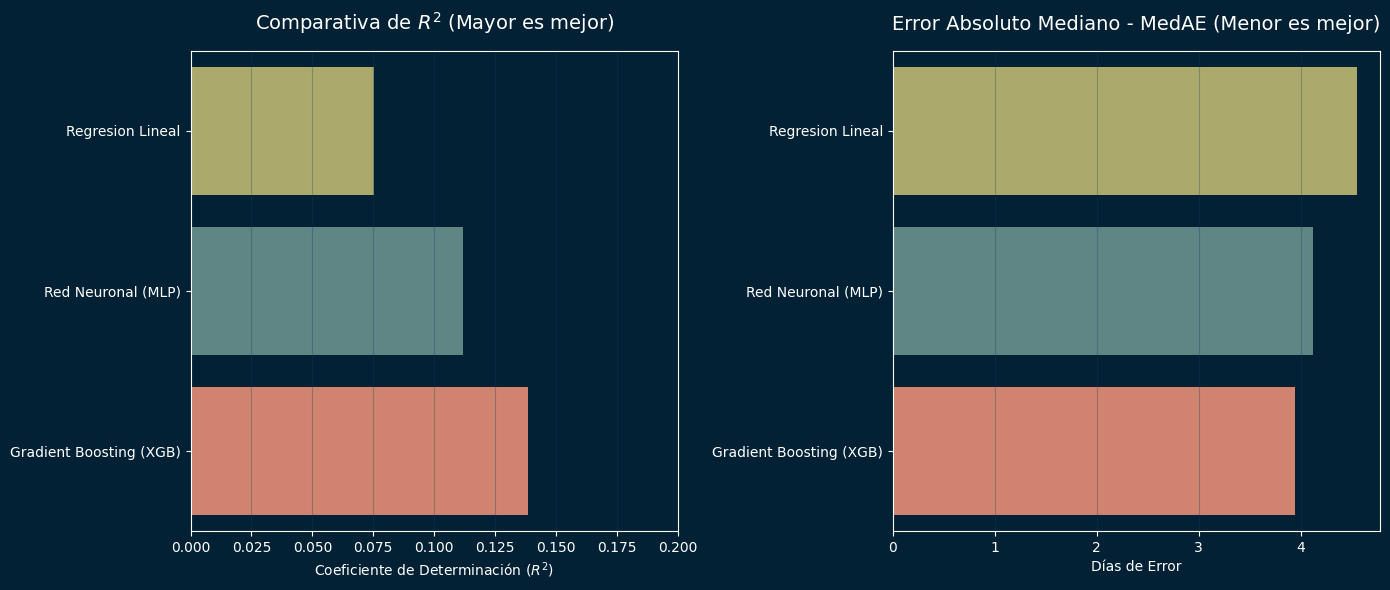

[
  {
    "Modelo": "Regresion Lineal",
    "R2": 0.07513628287935803,
    "MedAE (Dias)": 4.551314355370641,
    "RMSE (Dias)": 28.25405192336411
  },
  {
    "Modelo": "Red Neuronal (MLP)",
    "R2": 0.11195697662376225,
    "MedAE (Dias)": 4.1214154686189,
    "RMSE (Dias)": 27.710813607260878
  },
  {
    "Modelo": "Gradient Boosting (XGB)",
    "R2": 0.13838783576037972,
    "MedAE (Dias)": 3.9404482336371833,
    "RMSE (Dias)": 27.421284350685934
  }
]


In [41]:
# =========================================================
# 5. VISUALIZACIÓN DE MÉTRICAS (FONDO OSCURO)
# =========================================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='R2', y='Modelo', data=results_df, hue='Modelo', palette=palette_custom, legend=False)
plt.title('Comparativa de $R^2$ (Mayor es mejor)', fontsize=14, color=text_color, pad=15)
plt.xlabel('Coeficiente de Determinación ($R^2$)', color=text_color)
plt.ylabel('')
plt.xlim(0, 0.20)
plt.grid(axis='x', alpha=0.3)

plt.subplot(1, 2, 2)
sns.barplot(x='MedAE (Dias)', y='Modelo', data=results_df, hue='Modelo', palette=palette_custom, legend=False)
plt.title('Error Absoluto Mediano - MedAE (Menor es mejor)', fontsize=14, color=text_color, pad=15)
plt.xlabel('Días de Error', color=text_color)
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir tabla de resultados consolidados
print(json.dumps(results_df.to_dict(orient='records'), indent=2))

## 4. Explicabilidad Global

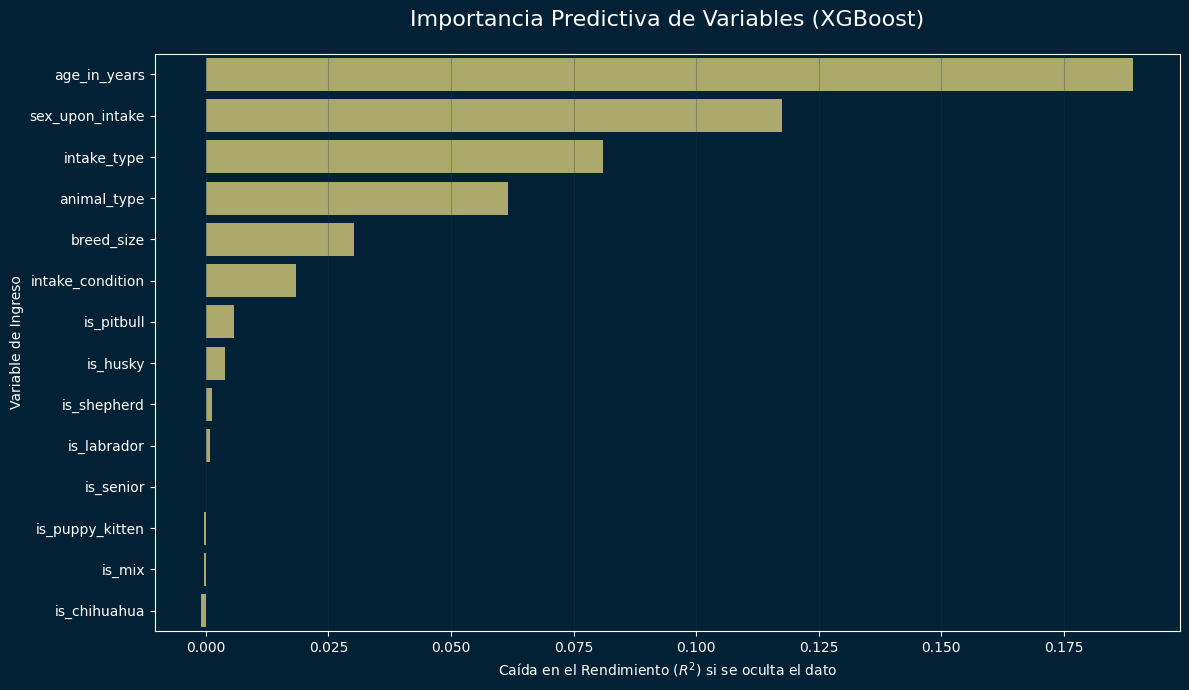

In [ ]:
# =========================================================
# 6. IMPORTANCIA DE VARIABLES (PERMUTATION IMPORTANCE)
# =========================================================
r = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': r.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=imp_df, color=accent_color)
plt.title('Importancia Predictiva de Variables (XGBoost)', fontsize=16, color=text_color, pad=20)
plt.xlabel('Caída en el Rendimiento ($R^2$) si se oculta el dato', color=text_color)
plt.ylabel('Variable de Ingreso', color=text_color)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Explicabilidad mediante SHAP

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


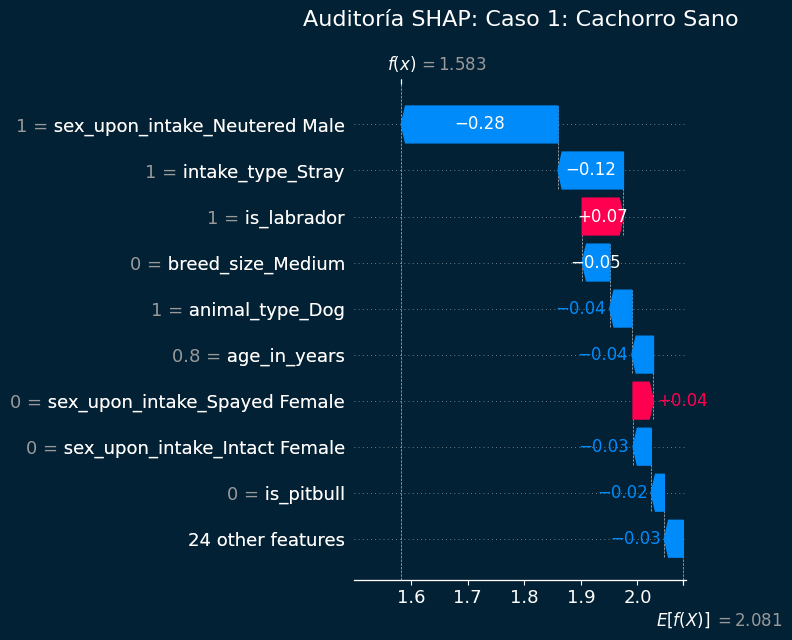

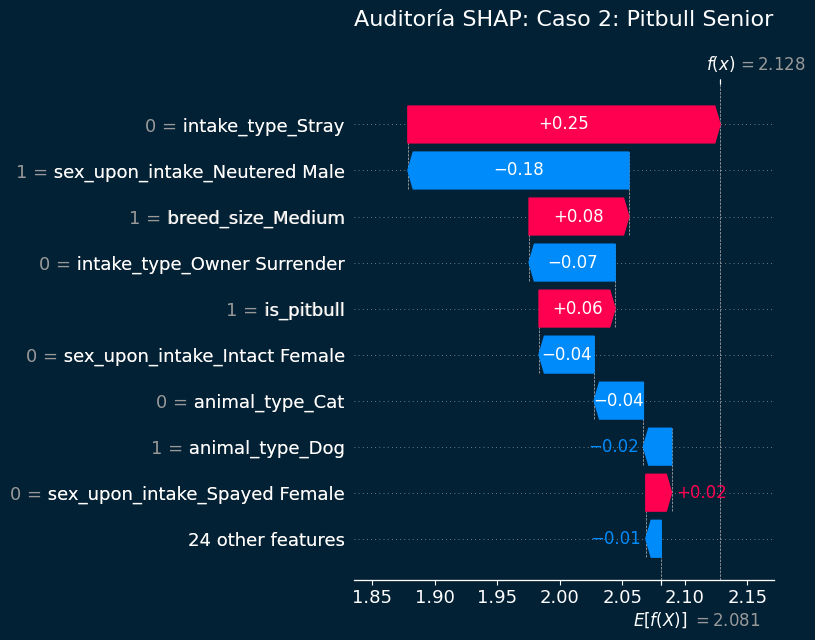

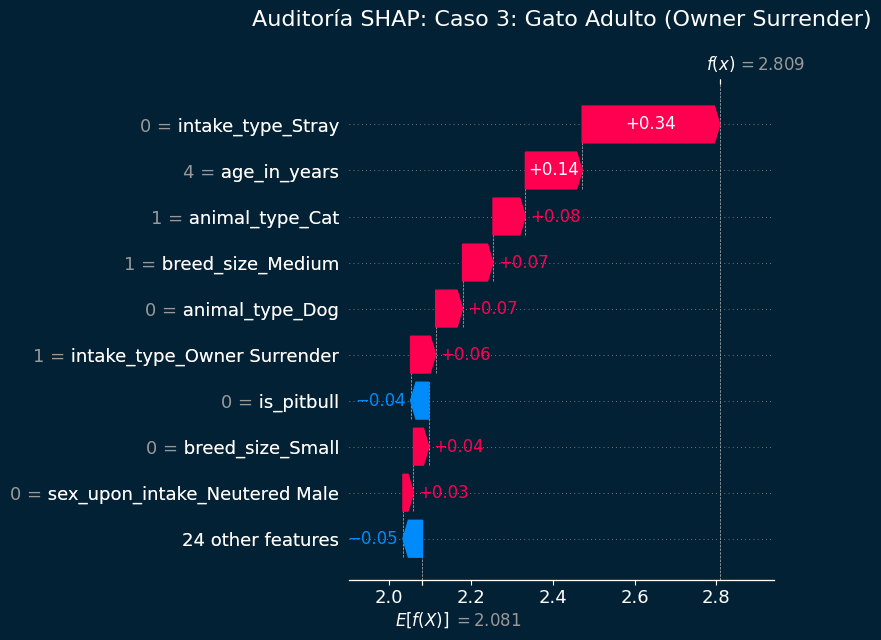

=== ALERTAS DEL MOTOR DE PREDICCIÓN ===


,animal_type,age_in_years,is_pitbull,intake_condition,Prediccion_Dias,Dias_Reales
61281,Dog,0.821918,0,Normal,3.868647,6.072222
2585,Dog,8.000000,1,Normal,7.400702,10.124306
61282,Cat,4.000000,0,Normal,15.585724,18.188889


In [ ]:
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
cat_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

# Usamos una muestra de fondo de 1000 casos
explainer = shap.Explainer(best_model.named_steps['regressor'].predict, X_test_transformed[:1000], feature_names=feature_names)

# Selección de los mismos casos tácticos
idx_cachorro = X_test[(X_test['is_puppy_kitten'] == 1) & (X_test['animal_type'] == 'Dog')].index[0]
idx_pitbull_senior = X_test[(X_test['is_pitbull'] == 1) & (X_test['is_senior'] == 1)].index[31]
idx_gato = X_test[(X_test['animal_type'] == 'Cat') & (X_test['intake_type'] == 'Owner Surrender') & (X_test['is_senior'] == 0) & (X_test['is_puppy_kitten'] == 0)].index[0]

indices_iloc = [X_test.index.get_loc(idx_cachorro), X_test.index.get_loc(idx_pitbull_senior), X_test.index.get_loc(idx_gato)]
casos_shap = X_test_transformed[indices_iloc]

# =========================================================
# 2. CÁLCULO SHAP Y SOBREESCRITURA DE VALORES REALES
# =========================================================
shap_values = explainer(casos_shap)

# TRUCO BI: Extraemos los valores brutos (sin escalar) de las variables numéricas
valores_reales_numericos = X_test.iloc[indices_iloc][numeric_features].values

# Interceptamos el objeto SHAP y reemplazamos los valores Z-Score por los reales
# (Las columnas numéricas son las primeras en nuestra matriz transformada)
for i in range(len(shap_values)):
    for j in range(len(numeric_features)):
        # Redondeamos la edad a 1 decimal para que se vea limpio en el gráfico
        if numeric_features[j] == 'age_in_years':
            shap_values[i].data[j] = np.round(valores_reales_numericos[i, j], 1)
        else:
            shap_values[i].data[j] = int(valores_reales_numericos[i, j])

# =========================================================
# 3. GENERACIÓN DE GRÁFICAS PARA LA PRESENTACIÓN
# =========================================================
perfiles = ['Caso 1: Cachorro Sano', 'Caso 2: Pitbull Senior', 'Caso 3: Gato Adulto (Owner Surrender)']

for i, nombre_perfil in enumerate(perfiles):
    # Crear la figura con el fondo institucional
    fig = plt.figure(figsize=(10, 6))
    
    # Generar el gráfico SHAP
    shap.plots.waterfall(shap_values[i], show=False)
    
    # Ajustes de formato para la presentación
    plt.title(f'Auditoría SHAP: {nombre_perfil}', fontsize=16, color=text_color, pad=20)
    plt.tight_layout()
    
    # Mostrar y/o guardar
    plt.show()

casos_info = X_test.iloc[indices_iloc].copy()
casos_info['Prediccion_Dias'] = np.expm1(best_model.predict(X_test.iloc[indices_iloc]))
casos_info['Dias_Reales'] = y_test_real.iloc[indices_iloc].values

print("=== ALERTAS DEL MOTOR DE PREDICCIÓN ===")
display(casos_info[['animal_type', 'age_in_years', 'is_pitbull', 'intake_condition', 'Prediccion_Dias', 'Dias_Reales']])

In [ ]:
import joblib

joblib.dump(best_model, 'motor_triaje_aac.pkl')
print("Modelo serializado y exportado exitosamente como 'motor_triaje_aac.pkl'")

Modelo serializado y exportado exitosamente como 'motor_triaje_aac.pkl'
